1. IMPORT LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

2. LOAD DATA & BASIC INSPECTION

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               

3. PREPROCESSING

In [3]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values('Date').reset_index(drop=True)

df['Region_enc'] = LabelEncoder().fit_transform(df['Region'])
df['Model_enc']  = LabelEncoder().fit_transform(df['Model'])
df['Source_enc'] = LabelEncoder().fit_transform(df['Source_Type'])

4. EDA

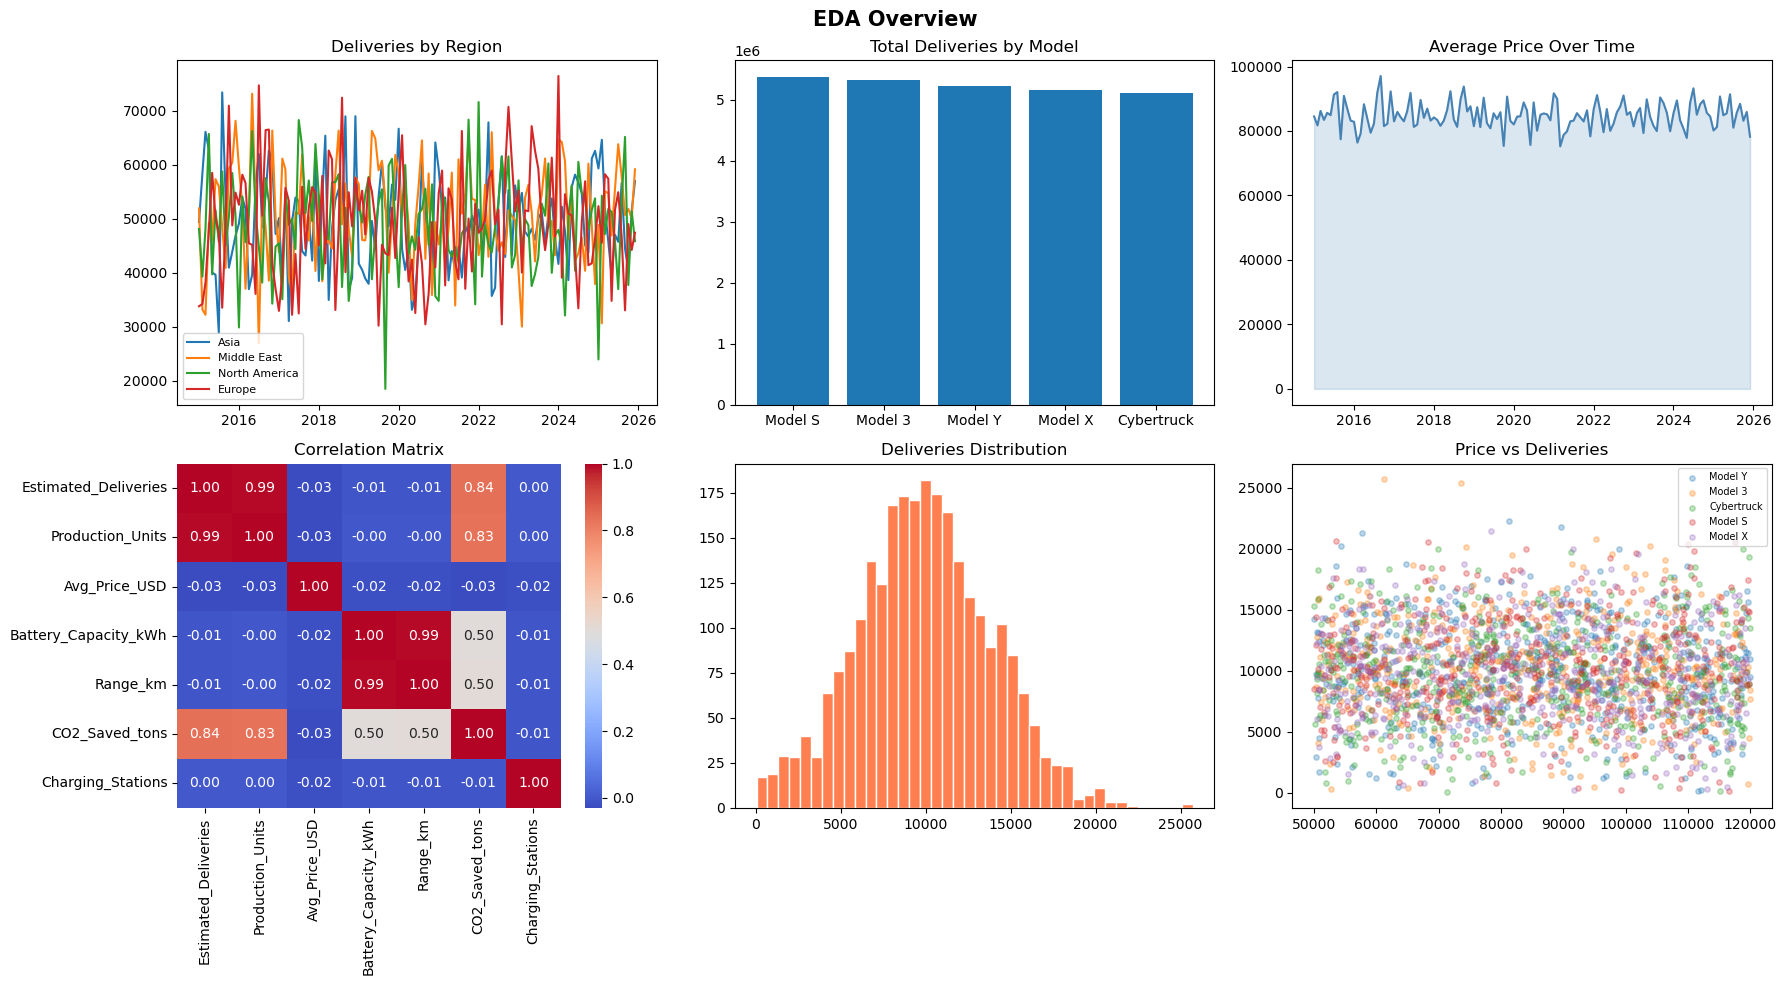

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA Overview', fontsize=15, fontweight='bold')

# Deliveries by region over time
for reg in df['Region'].unique():
    sub = df[df['Region'] == reg].groupby('Date')['Estimated_Deliveries'].sum()
    axes[0, 0].plot(sub.index, sub.values, label=reg, linewidth=1.5)
axes[0, 0].set_title('Deliveries by Region'); axes[0, 0].legend(fontsize=8)

# Total deliveries by model
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
axes[0, 1].bar(model_totals.index, model_totals.values)
axes[0, 1].set_title('Total Deliveries by Model')

# Avg price trend
avg_price = df.groupby('Date')['Avg_Price_USD'].mean()
axes[0, 2].plot(avg_price.index, avg_price.values, color='steelblue')
axes[0, 2].fill_between(avg_price.index, avg_price.values, alpha=0.2, color='steelblue')
axes[0, 2].set_title('Average Price Over Time')

# Correlation heatmap
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
sns.heatmap(df[num_cols].corr(), ax=axes[1, 0], cmap='coolwarm', annot=True, fmt='.2f')
axes[1, 0].set_title('Correlation Matrix')

# Distribution of deliveries
axes[1, 1].hist(df['Estimated_Deliveries'], bins=40, color='coral', edgecolor='white')
axes[1, 1].set_title('Deliveries Distribution')

# Price vs Deliveries scatter
for m in df['Model'].unique():
    sub = df[df['Model'] == m]
    axes[1, 2].scatter(sub['Avg_Price_USD'], sub['Estimated_Deliveries'], alpha=0.3, s=15, label=m)
axes[1, 2].set_title('Price vs Deliveries'); axes[1, 2].legend(fontsize=7)

plt.tight_layout()


5. FEATURE ENGINEERING

In [5]:
df['Price_Per_kWh']    = df['Avg_Price_USD']        / df['Battery_Capacity_kWh']
df['Range_Per_kWh']    = df['Range_km']             / df['Battery_Capacity_kWh']
df['Production_Ratio'] = df['Estimated_Deliveries'] / (df['Production_Units'] + 1)

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['Year_norm'] = (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min())

df['Deliveries_Lag1']  = df['Estimated_Deliveries'].shift(1).fillna(0)
df['Deliveries_Lag3']  = df['Estimated_Deliveries'].shift(3).fillna(0)
df['Deliveries_Roll3'] = df['Estimated_Deliveries'].rolling(3, min_periods=1).mean()

FEATURES = [
    'Year_norm', 'Month_sin', 'Month_cos', 'Region_enc', 'Model_enc',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'Production_Units', 'Charging_Stations', 'CO2_Saved_tons',
    'Price_Per_kWh', 'Range_Per_kWh', 'Production_Ratio',
    'Deliveries_Lag1', 'Deliveries_Lag3', 'Deliveries_Roll3'
]
TARGET = 'Estimated_Deliveries'

X = df[FEATURES]
y = df[TARGET]


6. REGRESSION MODELING

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    if 'Regression' in name:
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE':  mean_absolute_error(y_test, preds),
        'R2':   r2_score(y_test, preds),
        'preds': preds
    }
    print(f"{name:25s}  RMSE={results[name]['RMSE']:8.1f}  "
          f"MAE={results[name]['MAE']:8.1f}  R²={results[name]['R2']:.4f}")


Linear Regression          RMSE=   151.9  MAE=   104.4  R²=0.9985
Ridge Regression           RMSE=   151.9  MAE=   104.2  R²=0.9985
Random Forest              RMSE=   132.9  MAE=    66.9  R²=0.9988
Gradient Boosting          RMSE=    88.2  MAE=    63.8  R²=0.9995


7. HYPERPARAMETER TUNING (GridSearchCV)

In [7]:
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("\nBest params:", grid_search.best_params_)

tuned_preds = best_rf.predict(X_test)
print(f"Tuned RF  RMSE={np.sqrt(mean_squared_error(y_test, tuned_preds)):.1f}  "
      f"R²={r2_score(y_test, tuned_preds):.4f}")


Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF  RMSE=132.9  R²=0.9988


8. FEATURE IMPORTANCE

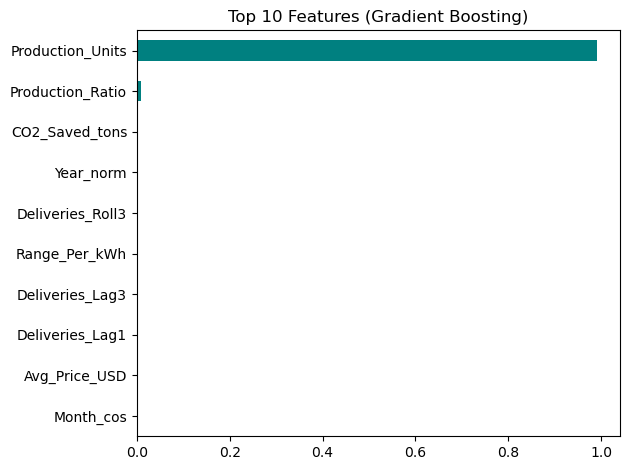

In [8]:
gb_best = results['Gradient Boosting']   
gb_model = models['Gradient Boosting']
importances = pd.Series(gb_model.feature_importances_, index=FEATURES).sort_values()
importances.tail(10).plot(kind='barh', color='teal',
                          title='Top 10 Features (Gradient Boosting)')
plt.tight_layout()


9. TIME-SERIES FORECASTING (SARIMA)

d:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


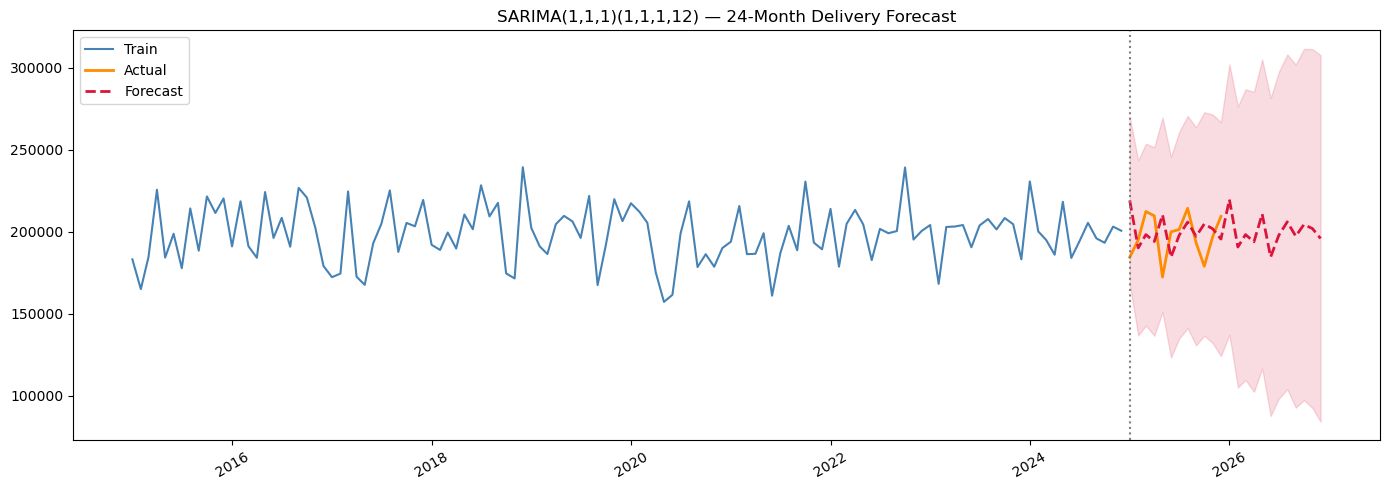

In [9]:
ts       = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()
train_ts = ts[:-12]
test_ts  = ts[-12:]

sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast = sarima_model.get_forecast(steps=24)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts.index, train_ts.values, label='Train',    color='steelblue')
ax.plot(test_ts.index,  test_ts.values,  label='Actual',   color='darkorange', linewidth=2)
ax.plot(fc_mean.index,  fc_mean.values,  label='Forecast', color='crimson',
        linestyle='--', linewidth=2)
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, color='crimson')
ax.axvline(test_ts.index[0], color='gray', linestyle=':')
ax.set_title('SARIMA(1,1,1)(1,1,1,12) — 24-Month Delivery Forecast')
ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()


10. CROSS-VALIDATION

In [10]:
cv_results = {}
for name in ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']:
    pipe  = Pipeline([('sc', StandardScaler()), ('m', models[name])])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_results[name] = (scores.mean(), scores.std())
    print(f"CV  {name:25s}  R² = {scores.mean():.4f} ± {scores.std():.4f}")

print("\nPipeline complete.")

CV  Linear Regression          R² = 0.9984 ± 0.0001
CV  Ridge Regression           R² = 0.9984 ± 0.0001
CV  Random Forest              R² = 0.9983 ± 0.0008
CV  Gradient Boosting          R² = 0.9992 ± 0.0005

Pipeline complete.
